# Introduction to Regression with Neural Network in TensorFlow

There are many definitions for a regression problem but in our case, we're going to simplify it: predicting a numerical variable based on some other combination of variables, even shorter... predicting a number.

## Typical architecture of a regresison neural network

The word *typical* is on purpose.

Why?

Because there are many different ways (actually, there's almost an infinite number of ways) to write neural networks.

But the following is a generic setup for ingesting a collection of numbers, finding patterns in them and then outputting some kind of target number.

Yes, the previous sentence is vague but we'll see this in action shortly.

| **Hyperparameter** | **Typical value** |
| --- | --- |
| Input layer shape | Same shape as number of features (e.g. 3 for # bedrooms, # bathrooms, # car spaces in housing price prediction) |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited |
| Neurons per hidden layer | Problem specific, generally 10 to 100 |
| Output layer shape | Same shape as desired prediction shape (e.g. 1 for house price) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) |
| Output activation | None, ReLU, logistic/tanh |
| Loss function | [MSE](https://en.wikipedia.org/wiki/Mean_squared_error) (mean square error) or [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) (mean absolute error)/Huber (combination of MAE/MSE) if outliers |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) |

*Table 1: Typical architecture of a regression network. Source: Adapted from page 293 of [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow Book by Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)*

Again, if you're new to neural networks and deep learning in general, much of the above table won't make sense. But don't worry, we'll be getting hands-on with all of it soon.

> 🔑 **Note:** A **hyperparameter** in machine learning is something a data analyst or developer can set themselves, where as a **parameter** usually describes something a model learns on its own (a value not explicitly set by an analyst).

Okay, enough talk, let's get started writing code.

To use TensorFlow, we'll import it as the common alias `tf` (short for TensorFlow).

In [1]:
# Import TensorFlow
import tensorflow as tf
print(tf.__version__) # check the version

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

2.10.0
Notebook last run (end-to-end): 2026-09-20 15:01:55.227739


## Creating data to view and fit

since we're working on **regression problem** (predicting a number) let's create some linear data (a straight line) to model.

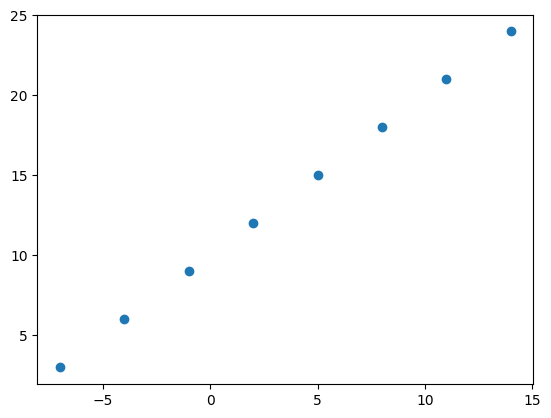

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0]).reshape(-1, 1)

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

In [25]:
y  == X + 10

array([[ True, False, False, False, False, False, False, False],
       [False,  True, False, False, False, False, False, False],
       [False, False,  True, False, False, False, False, False],
       [False, False, False,  True, False, False, False, False],
       [False, False, False, False,  True, False, False, False],
       [False, False, False, False, False,  True, False, False],
       [False, False, False, False, False, False,  True, False],
       [False, False, False, False, False, False, False,  True]])

Before we do any modelling, can you calculate the pattern between `X` and `y`?

For example, say I asked you, based on this data what the `y` value would be if `X` was 17.0?

Or how about if `X` was -10.0?

This kind of pattern discovery is the essence of what we'll be building neural networks to do for us.

## Regression input  and output shapes

One of the most important concepts when working with neural networks are the input and output shapes.

The **input shape** is the shape of your data that goes into the model.

The **output shape** is the shape of your data you want to come out of you model.
These will differ depending on the problem you're working on.

Neural networks accept numbers and output numbers. These numbers are typically represented as tensors (or arrays).

Before, we created data using NumPy arrays, but we could do the same with tensors.

In [26]:
# Create a demo tensor for our housing price prediction problem
# Example input and output shapes of a regression model
house_info = tf.constant(['bedroom', 'bathroom', 'garage'])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700])>)

In [27]:
house_info.shape

TensorShape([3])

In [28]:
X[0], y[0]

(array([-7.]), 3.0)

In [29]:
X[1], y[1]

(array([-4.]), 6.0)

In [30]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

((1,), ())

In [31]:
X[0].ndim

1

In [32]:
X[0], y[0]

(array([-7.]), 3.0)

In [43]:
# Turn our NumPy arrays into tensor
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [34]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([1]), TensorShape([]))

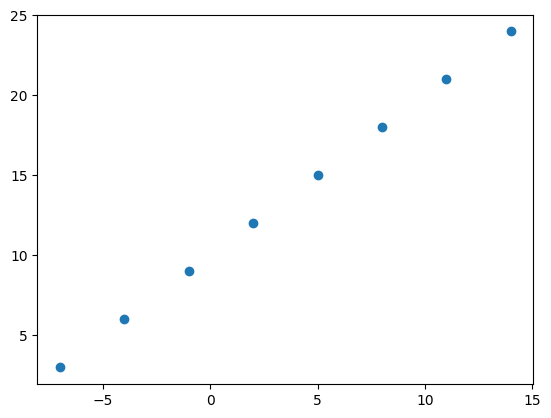

In [35]:
plt.scatter(X, y)

## Steps in modellin with TensorFlow

1. **Creating a model** - define the input and output layers, as well as the hidden layers of a deep learning model.
2. **Compiling a model** - define the loss function (in others words, the function which tells our model how wrong it is) and the optimizer (tells our model how to improve the patterns its learning) and evaluation metricx (what we can use to interpret the performance of our model).
3. **Fitting a model** - letting the model try to find patterns between X & y (features and labels).

In [36]:
# model = tf.keras.Sequential()
# model.add(tf.keras.layers.Dense(1))

In [62]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(
    loss=tf.keras.losses.mae,  # mae is short for mean absolute error
    optimizer=tf.keras.optimizers.SGD(), # sgd is short for stochastic gradient descent
    metrics=['mae']
)

# 3. Fit the model
model.fit(X, y, epochs=5)

Epoch 1/5
1/1 [==============================] - 0s 167ms/step - loss: 11.3212 - mae: 11.3212
Epoch 2/5
1/1 [==============================] - 0s 0s/step - loss: 11.1887 - mae: 11.1887
Epoch 3/5
1/1 [==============================] - 0s 9ms/step - loss: 11.0562 - mae: 11.0562
Epoch 4/5
1/1 [==============================] - 0s 2ms/step - loss: 10.9237 - mae: 10.9237
Epoch 5/5
1/1 [==============================] - 0s 3ms/step - loss: 10.7912 - mae: 10.7912


In [63]:
model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [111]:
# from tensorflow.keras.utils import plot_model

# plot_model(model, show_shapes=True)

In [65]:
# Check out X and y
X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [66]:
# Try and make a prediction using our model
y_pred = model.predict([17.0])
y_pred

1/1 [==============================] - 0s 39ms/step


array([[13.607917]], dtype=float32)

In [67]:
y_pred + 11

array([[24.607918]], dtype=float32)

## Improving our model

We can improve our model, by altering the steps we took to create a model.

1. **Creatin a model** - here we might add more layers, increase the number of hidden units (also called neurons) within each of the hidden layers, change the activation function of each layer.
2. **Compiling a model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function.
3. **Fitting a model** - here we might fit a model for more **epochs** (leave it training for longer) or on more data (give the model more examples to learn from)

In [79]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer='sgd',
              metrics=['mae'])

# 3. Fit the model (this time we'll train for longer)
model.fit(X, y, epochs=1500)

Epoch 1/1500
1/1 [==============================] - 0s 135ms/step - loss: 11.5295 - mae: 11.5295
Epoch 2/1500
1/1 [==============================] - 0s 0s/step - loss: 11.3970 - mae: 11.3970
Epoch 3/1500
1/1 [==============================] - 0s 7ms/step - loss: 11.2645 - mae: 11.2645
Epoch 4/1500
1/1 [==============================] - 0s 0s/step - loss: 11.1320 - mae: 11.1320
Epoch 5/1500
1/1 [==============================] - 0s 8ms/step - loss: 10.9995 - mae: 10.9995
Epoch 6/1500
1/1 [==============================] - 0s 0s/step - loss: 10.8670 - mae: 10.8670
Epoch 7/1500
1/1 [==============================] - 0s 0s/step - loss: 10.7345 - mae: 10.7345
Epoch 8/1500
1/1 [==============================] - 0s 8ms/step - loss: 10.6020 - mae: 10.6020
Epoch 9/1500
1/1 [==============================] - 0s 0s/step - loss: 10.4695 - mae: 10.4695
Epoch 10/1500
1/1 [==============================] - 0s 0s/step - loss: 10.3370 - mae: 10.3370
Epoch 11/1500
1/1 [==============================] - 

In [80]:
# Remind ourselves of the data
X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [81]:
# Let's see if our model's prediction has improved..
model.predict([17.0])

1/1 [==============================] - 0s 33ms/step


array([[27.308352]], dtype=float32)

In [104]:
# Let's see if we can make another to improve our model

# 1. Create the model (this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(
    loss='mae',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics='mae'
)

# 3. Fit the model
model.fit(X, y, epochs=100)

Epoch 1/100
1/1 [==============================] - 0s 192ms/step - loss: 14.3572 - mae: 14.3572
Epoch 2/100
1/1 [==============================] - 0s 2ms/step - loss: 13.4071 - mae: 13.4071
Epoch 3/100
1/1 [==============================] - 0s 2ms/step - loss: 12.4622 - mae: 12.4622
Epoch 4/100
1/1 [==============================] - 0s 2ms/step - loss: 11.5168 - mae: 11.5168
Epoch 5/100
1/1 [==============================] - 0s 2ms/step - loss: 10.5659 - mae: 10.5659
Epoch 6/100
1/1 [==============================] - 0s 2ms/step - loss: 9.6044 - mae: 9.6044
Epoch 7/100
1/1 [==============================] - 0s 2ms/step - loss: 8.6264 - mae: 8.6264
Epoch 8/100
1/1 [==============================] - 0s 3ms/step - loss: 7.6252 - mae: 7.6252
Epoch 9/100
1/1 [==============================] - 0s 2ms/step - loss: 6.6788 - mae: 6.6788
Epoch 10/100
1/1 [==============================] - 0s 1ms/step - loss: 6.8193 - mae: 6.8193
Epoch 11/100
1/1 [==============================] - 0s 2ms/step - l

In [106]:
# Let's remind ourselves of the data
X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [107]:
# Let's try to make a prediction
model.predict([17.0])

1/1 [==============================] - 0s 43ms/step


array([[26.143612]], dtype=float32)

### Evaluating a model

In practice, a typical workflo you'll go thrugh when building neural network is:

> Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it...


When it comes to evaluation... there are 3 words you should memorize:
> "Visualize, Visualize, visualize"

It's a good idea to visualize:
* The data - what data are we working with? What does it look like?
* The model itself - what does our model look like?
* The training of a model - how does a model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against the gorund truth (the original labels)?

In [108]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])>

In [110]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>